In [2]:
!pip install numpy -q
!pip install matplotlib -q
!pip install pillow -q
!pip install pandas -q
!pip install scikit-learn -q
!pip install tqdm -q
!pip install gdown -q

In [3]:
# Check is at least python 3.9
import sys
assert (sys.version_info.major == 3) and (sys.version_info.minor >= 9)

In [4]:
import platform

# Get os name
os_name = platform.system().lower()

# OS X
if os_name == 'darwin':
    print("Detected OS X")
    %pip install torch torchvision torchaudio -q

#Windows
elif os_name == 'windows':
    print("Detected Windows")
    %pip install torch torchvision torchaudio -q

# Linux
else:
    print("Detected Linux")
    %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu -q

Detected Windows
Note: you may need to restart the kernel to use updated packages.


In [144]:
# Import main packages
%reload_ext autoreload 
%autoreload 2 

import os
import copy
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd ########
import cv2

import core
import features
import presence
import template

import zones
import card_isolation

#from UNO import * ###
from pathlib import Path #######
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from typing import Optional, Callable
from sklearn.metrics import accuracy_score, f1_score
from sklearn.covariance import LedoitWolf


### Each image is an object. It can return:
- its informations from the .csv 
- the .jpg from train_images 

white background
p1


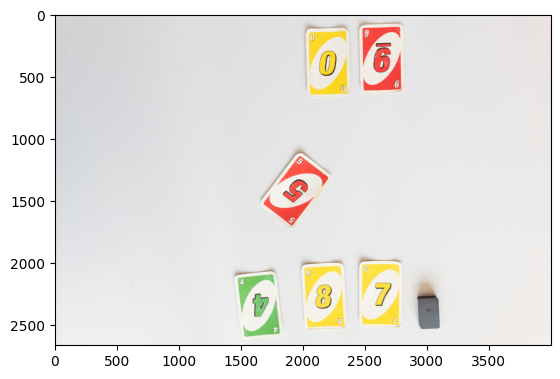

In [17]:
image1 = core.image(core.valid_nb(1))

image1.draw(500, 501, 1500, 2500, core.BLACK)
print(image1.show_info(core.IDX.ACTIVE_PLAYER))

image1.display(temporary=False)


### Check active players 
Done only with std <=> works for white background

In [18]:
presence.TEST_search_present()

Presence classifier not trained. Please train it first.


0

### TEST SIFT-algo

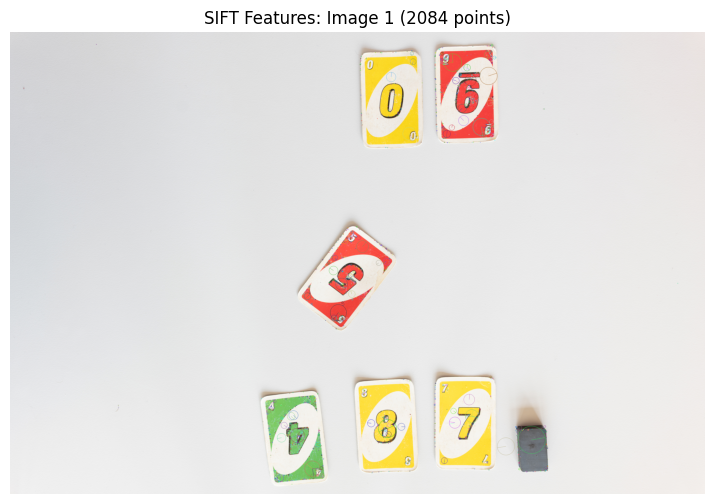

In [19]:
features.visualize_sift(image1)

### TEST ORB-algo

Checking ORB output for 3 samples...


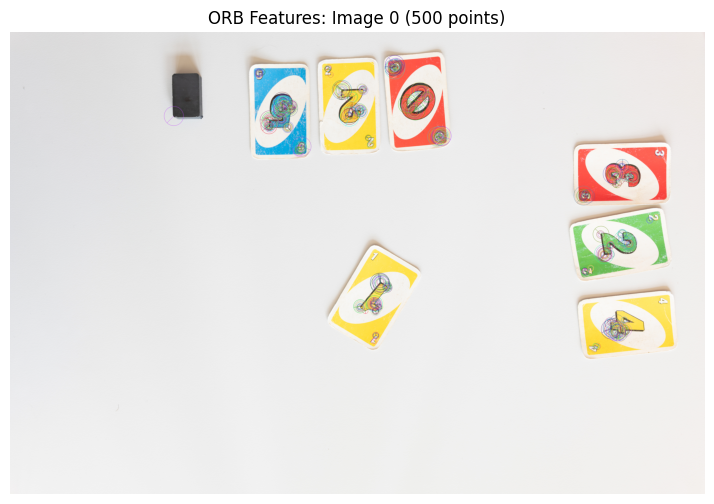

Sample 0: Descriptors shape (500, 32)


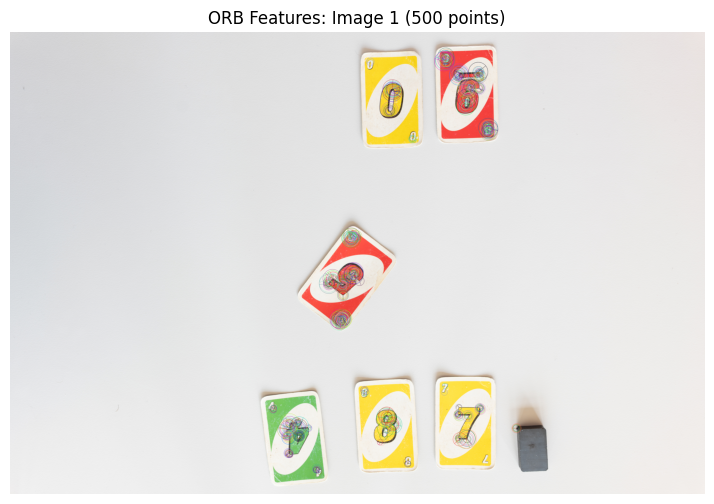

Sample 1: Descriptors shape (500, 32)


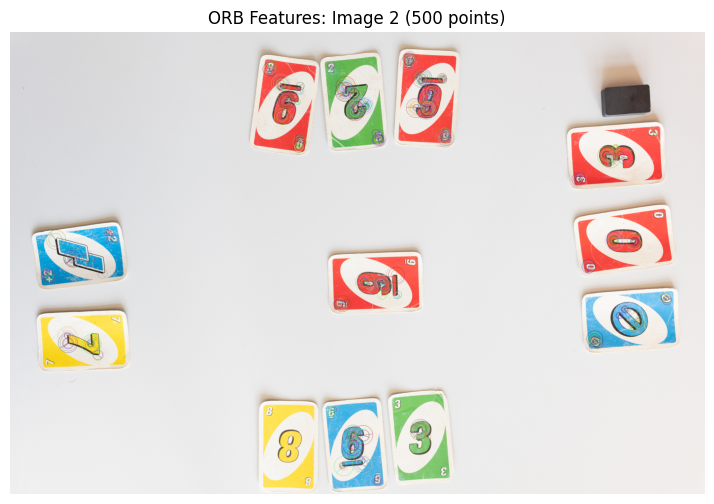

Sample 2: Descriptors shape (500, 32)
Inspection complete.


In [20]:
features.TEST_orb_quality()

### Extracting features of unitary cards

In [31]:
templates_folder_path = Path("../data/images_crop/")
card_feature_database = template.build_card_feature_db(str(templates_folder_path))

Building feature database from 54 templates...


100%|██████████| 54/54 [00:00<00:00, 100.79it/s]

Database built with 54 cards.


In [22]:
# Test à la con
print(len(card_feature_database))

for card_name, descriptors in card_feature_database.items():
    print(f"  Card: {card_name}, Descriptors shape: {descriptors.shape}")

0


### Tuning the areas for each players

In the function image.segment(), we define the are that will be used to train the Mahalanobis classifier. We need to be sure that these areas indeed include each players positions. 

So we use the .draw() of each image and pass it the return of the .segment() functions until we are happy with it.

white background
(2662, 4000, 3)


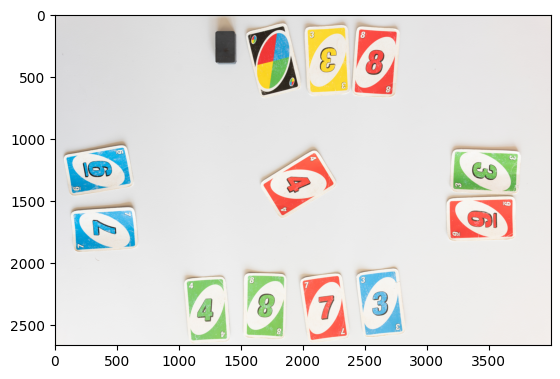

In [44]:
image2 = core.image(core.valid_nb(4))
x = image2.get()
print(x.shape)
image2.display(temporary = False)

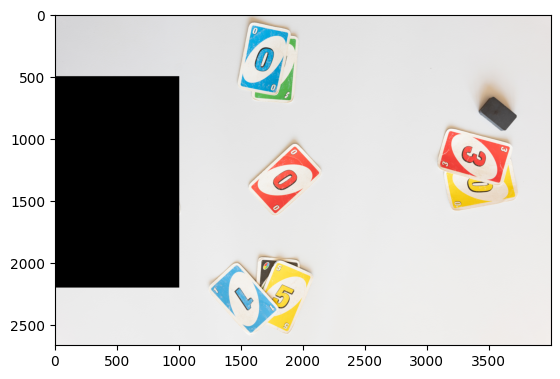

In [39]:
image2.draw(500, 2200, 0, 1000, core.BLACK)
image2.display(temporary = True)

### Start training Mahalanobis classifier

In [25]:
import presence

# Train the presence model on the images : 0-> n-1
n = 10 # all white background, 10 is clearly enough
model = presence.train_presence_classifier(num_train_images=n)

# Test it on the images : n -> m-1
m = 20
presence.TEST_search_present(model=model, num_train_images=n, num_total_images = m)

Training presence classifier on 10 images...
Training complete.

Testing presence detection on images from 10 to 19...
Image 13, Area 3: GUESS=True (predicted), ANSWER=EMPTY (ground truth)
Image 13, Area 4: GUESS=True (predicted), ANSWER=EMPTY (ground truth)
Image 14, Area 1: GUESS=True (predicted), ANSWER=EMPTY (ground truth)
Image 14, Area 3: GUESS=True (predicted), ANSWER=EMPTY (ground truth)
Image 15, Area 3: GUESS=True (predicted), ANSWER=EMPTY (ground truth)
Image 17, Area 1: GUESS=True (predicted), ANSWER=EMPTY (ground truth)
Image 19, Area 1: GUESS=True (predicted), ANSWER=EMPTY (ground truth)

--- Presence Detection Test Results ---
Total Areas Tested: 50
Accuracy: 0.8600
F1-Score: 0.9176
---------------------------------------
Presence detection test finished.


In [26]:
image = core.image(13)
plt.imshow(image.segment(3))

AttributeError: 'image' object has no attribute 'segment'

##### We realise that our classifier identifies a player as active, as soon as it detects a few pixels else than background (white background at this point). So we will actually tune the areas in the function .segment() in order to voluntarily include small pieces of other cards eventhough the player we check is "EMPTY".

(for instance, we had defined the area 1 as: [1800:2642, 1000:3000]

which we modify in :    [HEIGHT/2:HEIGHT, 0:WIDTH])

In [28]:
import presence

# Train the presence model on the images : 0-> n-1
n = 12
model = presence.train_presence_classifier(num_train_images=n)

# Test it on the images : n -> m-1
m = 21 # <=81
presence.TEST_search_present(model=model, num_train_images=n, num_total_images = m)

Training presence classifier on 12 images...
Training complete.

Testing presence detection on images from 12 to 20...
Image 13, Area 3: GUESS=True (predicted), ANSWER=EMPTY (ground truth)
Image 13, Area 4: GUESS=True (predicted), ANSWER=EMPTY (ground truth)
Image 14, Area 1: GUESS=True (predicted), ANSWER=EMPTY (ground truth)
Image 17, Area 1: GUESS=True (predicted), ANSWER=EMPTY (ground truth)
Image 20, Area 4: GUESS=True (predicted), ANSWER=EMPTY (ground truth)

--- Presence Detection Test Results ---
Total Areas Tested: 45
Accuracy: 0.8889
F1-Score: 0.9315
---------------------------------------
Presence detection test finished.


### honnêtement c'est pas ouf. On va direct comparer les features aux areas, sans passer pr du "est-ce que c'est EMPTY ou non?"

In [33]:
%reload_ext autoreload 
%autoreload 2 
import core
import template

# Use the database already built
print(len(card_feature_database))

n = 2
for i in range(n):
    imx = core.image(i)
    game_state = template.predict_table_state(imx, card_feature_database, presence_model= None, max_number_values=6)

    print(f"{i}: ANSWER:{imx.show_info(core.IDX.CENTER_CARD)} ==> guess:{game_state['Center']}  ")
    print(f"{i}: ANSWER:{imx.show_info(core.IDX.PLAYER_1_CARDS)} ==> guess:{game_state['Player 1']}")
    print(f"{i}: ANSWER:{imx.show_info(core.IDX.PLAYER_2_CARDS)} ==> guess:{game_state['Player 2']}")
    print(f"{i}: ANSWER:{imx.show_info(core.IDX.PLAYER_3_CARDS)} ==> guess:{game_state['Player 3']}")
    print(f"{i}: ANSWER:{imx.show_info(core.IDX.PLAYER_4_CARDS)} ==> guess:{game_state['Player 4']}")

54
0: ANSWER:y_1 ==> guess:['y_1 (164)', 'y_1 (41)']  
0: ANSWER:EMPTY ==> guess:['EMPTY']
0: ANSWER:y_4;g_2;r_3 ==> guess:['r_3 (104)', 'y_4 (97)', 'y_4 (24)']
0: ANSWER:r_skip;y_2;b_5 ==> guess:['y_2 (107)', 'r_skip (55)', 'b_5 (30)', 'y_2 (24)']
0: ANSWER:EMPTY ==> guess:['EMPTY']
1: ANSWER:r_5 ==> guess:['r_5 (28)', 'r_5 (24)']  
1: ANSWER:y_7;y_8;g_4 ==> guess:['y_8 (77)', 'g_4 (27)', 'y_7 (24)']
1: ANSWER:EMPTY ==> guess:['EMPTY']
1: ANSWER:r_9;y_0 ==> guess:['r_9 (181)', 'y_0 (52)', 'g_9 (25)', 'r_9 (25)']
1: ANSWER:EMPTY ==> guess:['EMPTY']


## Average image to hardcode each player's region

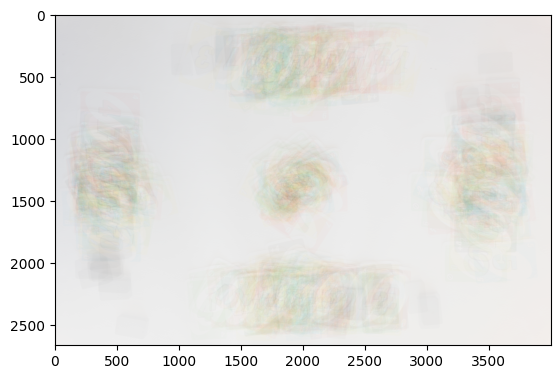

In [ ]:
im = core.get_average_image(40)
plt.imshow(im)
plt.imsave('average_pattern.png', im)

In [43]:
im.shape

(2662, 4000, 3)

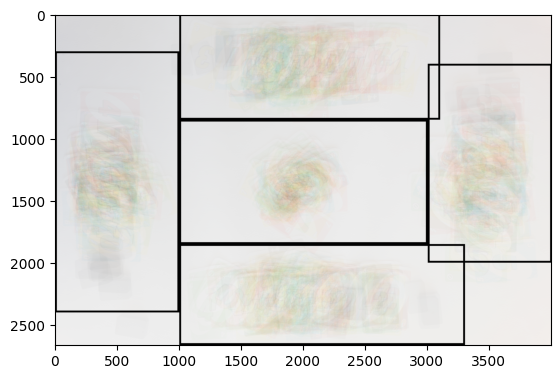

In [ ]:
regions = core.drawing(im, 1850, 2662, 1000, 3300, core.BLACK) #player 1
regions = core.drawing(regions, 400, 2000, 3000, 4000, core.BLACK) # player 2
regions = core.drawing(regions, 0, 850, 1000, 3100, core.BLACK) #player 3
regions = core.drawing(regions, 300, 2400, 0, 1000, core.BLACK) # player 4
regions = core.drawing(regions, 850, 1850, 1000, 3000, core.BLACK) # middle 

plt.imshow(regions)

white background


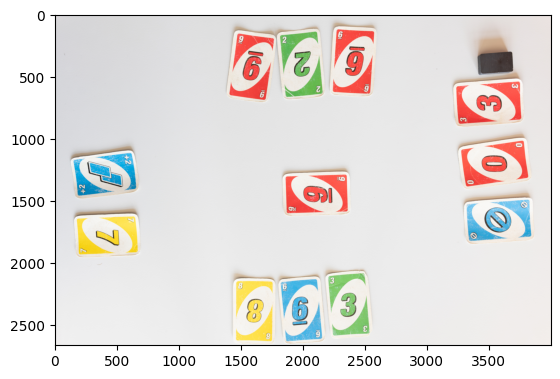

In [ ]:
x = core.image(core.valid_nb(2))
x.display(temporary=True)

x = x.get()
a, b, c, d, e = zones.extract_zones(x)

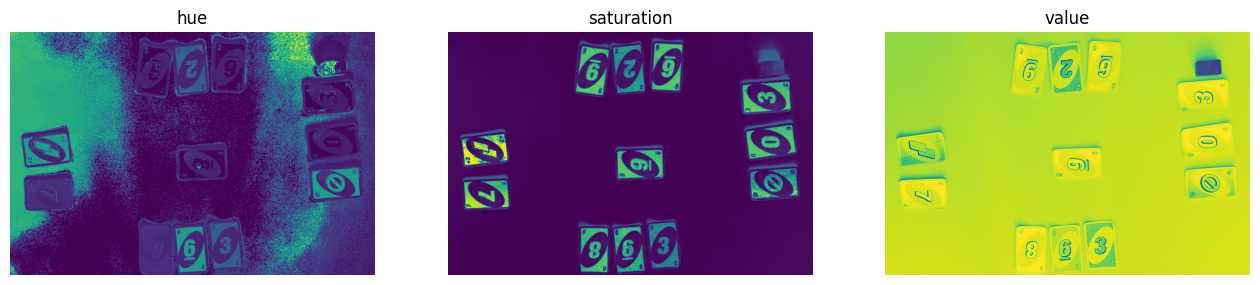

In [90]:
core.plot_hsv(x)

white background


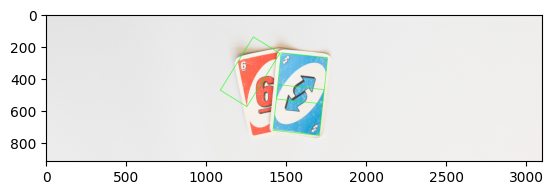

In [134]:
x = core.image(core.valid_nb(40))
x = x.get()
a, b, c, d, e = zones.extract_zones(x)

candidates, im = card_isolation.isolate_cards_new(a, white_background=True, plot_debug=False)
# Avec un threshold de 75 on voit quasiment plus le ptit merdier qui dit à qui c le tour
plt.imshow(im)

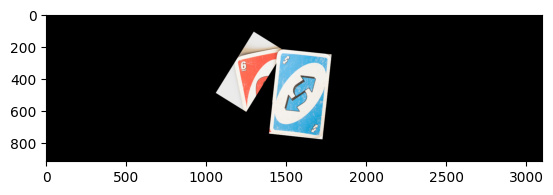

In [146]:
region_masked = card_isolation.mask_rectangles(a, candidates)

plt.imshow(region_masked)

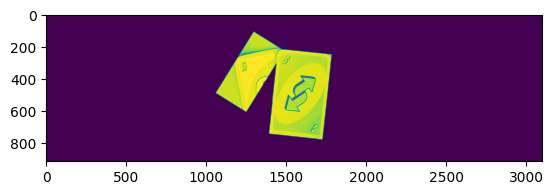

In [147]:
hsv = cv2.cvtColor(region_masked, cv2.COLOR_RGB2HSV)
v = hsv[:, :, 2] 

plt.imshow(v)

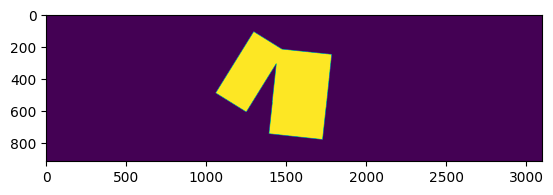

In [ ]:
_, mask = cv2.threshold(v, 50, 255, cv2.THRESH_BINARY) # (im, threshold, value given to pixel>threshold, thresholding type)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
plt.imshow(mask)